In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os

In [2]:
df = xr.open_dataset("SC_1995-2014.nc", engine="netcdf4")
var_soilm = df["H2OSOI"]
var_soilm

/tmp/ipykernel_157690/2461120404.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("SC_1995-2014.nc", engine="netcdf4")


<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

In [3]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_m"}, inplace=True)
    return obs

In [4]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = "SC_obs/soil_moisture"
observe = {}

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.update({f"{filename}":df})

In [5]:
for x in observe:
  print(observe[x]) 

                            time  obs_m
0      2008-01-01 00:00:00+00:00    NaN
1      2008-01-01 00:30:00+00:00    NaN
2      2008-01-01 01:00:00+00:00    NaN
3      2008-01-01 01:30:00+00:00    NaN
4      2008-01-01 02:00:00+00:00    NaN
...                          ...    ...
167365 2017-07-18 18:30:00+00:00  0.756
167366 2017-07-18 19:00:00+00:00  0.756
167367 2017-07-18 19:30:00+00:00  0.756
167368 2017-07-18 20:00:00+00:00  0.757
167369 2017-07-18 20:30:00+00:00  0.757

[167370 rows x 2 columns]
                          time  obs_m
0    2011-09-12 22:00:00+00:00  0.450
1    2011-09-13 02:00:00+00:00  0.449
2    2011-09-13 06:00:00+00:00  0.449
3    2011-09-13 10:00:00+00:00  0.448
4    2011-09-13 14:00:00+00:00  0.446
...                        ...    ...
4488 2013-09-29 22:00:00+00:00  0.538
4489 2013-09-30 02:00:00+00:00  0.539
4490 2013-09-30 06:00:00+00:00  0.541
4491 2013-09-30 10:00:00+00:00  0.541
4492 2013-09-30 14:00:00+00:00  0.539

[4493 rows x 2 columns]
            

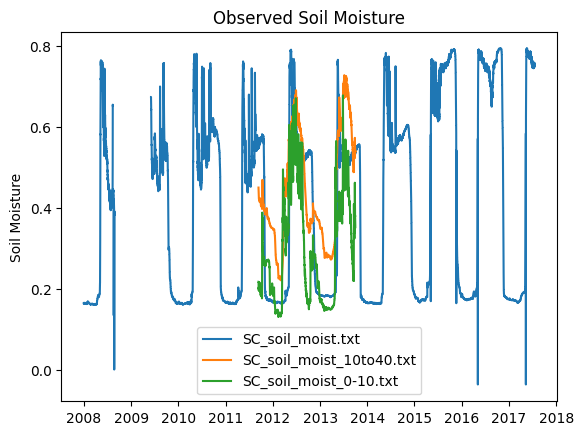

In [6]:
for data in observe:  
    plt.plot(observe[data]["time"], observe[data]["obs_m"], label=f"{data}")
plt.ylabel("Soil Moisture")
plt.title("Observed Soil Moisture")
plt.legend()
plt.show()

In [7]:
var_soilm

<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

Units are actually the same and the initial graph looks fine so no conversion or cleaning needed, but I'm just gonna stick with one file cause its infinitely more complete.

In [8]:
# obs_clean = {}
# for n in observe:
#     observe[n]["obs_depth"] = observe[n]["obs_depth"]/1000
#     #obs1_cleaned = obs1[obs1["obs_depth"] >= 0]
#     observe[n] = observe[n][observe[n]["obs_depth"] >= 0]
#     observe[n]["time"] = pd.to_datetime(observe[n]["time"])
#     obs_clean.update({f"{n}":observe[n]})
    

# for x in obs_clean:
#   print(obs_clean[x]) 

In [9]:
for x in observe:
    print(x)

SC_soil_moist.txt
SC_soil_moist_10to40.txt
SC_soil_moist_0-10.txt


In [10]:
#obs_concat = pd.concat(obs_clean, ignore_index=True, sort=True)
obs_concat = observe["SC_soil_moist.txt"]
print(obs_concat)

                            time  obs_m
0      2008-01-01 00:00:00+00:00    NaN
1      2008-01-01 00:30:00+00:00    NaN
2      2008-01-01 01:00:00+00:00    NaN
3      2008-01-01 01:30:00+00:00    NaN
4      2008-01-01 02:00:00+00:00    NaN
...                          ...    ...
167365 2017-07-18 18:30:00+00:00  0.756
167366 2017-07-18 19:00:00+00:00  0.756
167367 2017-07-18 19:30:00+00:00  0.756
167368 2017-07-18 20:00:00+00:00  0.757
167369 2017-07-18 20:30:00+00:00  0.757

[167370 rows x 2 columns]


## CTSM Interpolation

CTSM reports values at layer midpoints. This means for values like 10, I need to linearly interpolate to get the correct moisture values.

In [13]:
# Squeeze out the size-1 spatial dims for a point simulation
sm = var_soilm.squeeze()  # shape: (time, levgrnd)

# Get actual layer depths from the file (preferred over hardcoding)
depths = df["levsoi"].values  # shape: (levsoi,)
time   = df["time"].values

KeyError: 'levsoi'

In [ ]:
sim = var_soilm.isel(levsoi=0)
sim['time'] = sim.indexes['time'].to_datetimeindex()


/tmp/ipykernel_129833/2431337712.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
/tmp/ipykernel_129833/2431337712.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


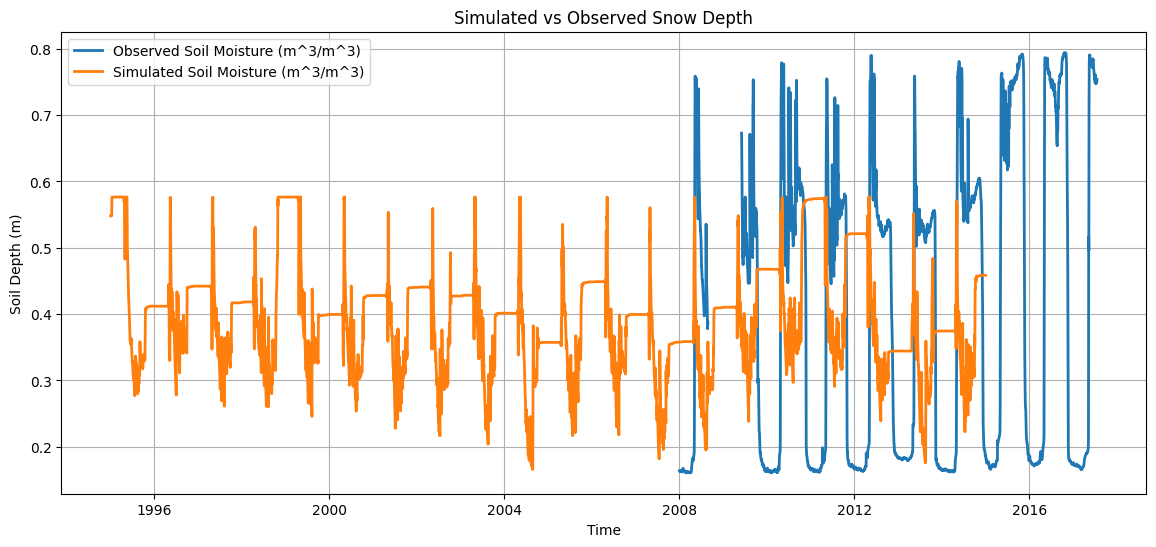

In [ ]:
# Convert pandas → xarray
obs = obs_concat.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_m"].values,
    label="Observed Soil Moisture (m^3/m^3)",
    linewidth=2
)

# Simulated
plt.plot(
    sim["time"].values,
    sim.values,
    label="Simulated Soil Moisture (m^3/m^3)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Moisture (m^3/m^3)")
plt.title("Simulated vs Observed Soil Moisture")
plt.grid(True)
plt.legend()
#plt.savefig("0_final_images/soil_moisture.png")
plt.show()